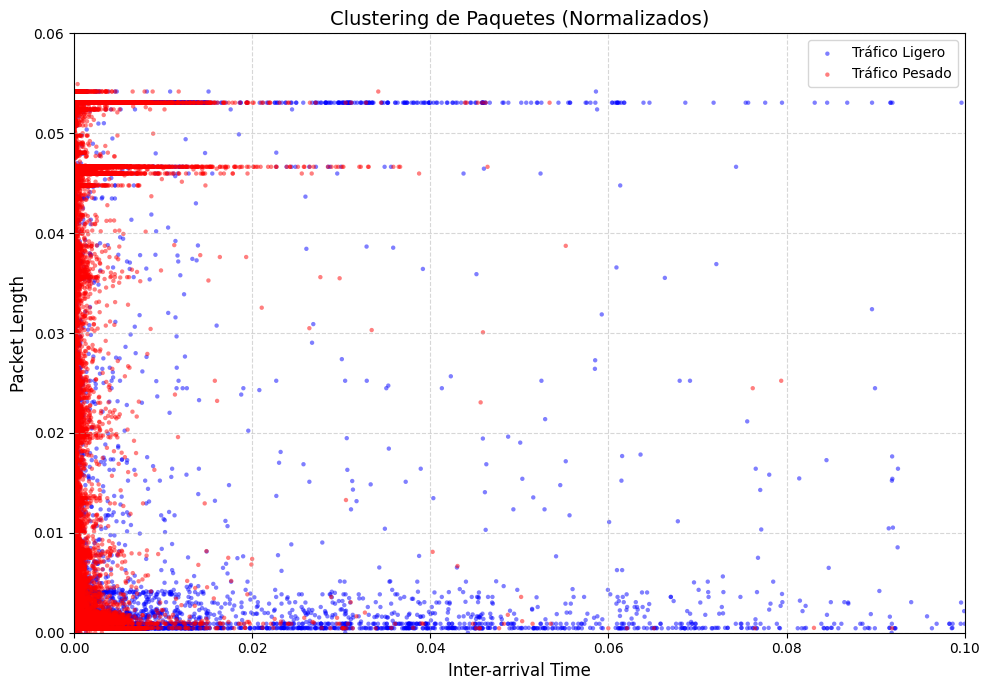

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

archivo_ligero = 'traficoligero.parquet'
archivo_pesado = 'traficopesado.parquet'

try:
    df_ligero = pd.read_parquet(archivo_ligero)
    df_pesado = pd.read_parquet(archivo_pesado)
except FileNotFoundError:
    print("Error: No se encuentran los archivos .parquet.")
    exit()
except ImportError:
    print("Error: Necesitas instalar pyarrow. Ejecuta: pip install pyarrow")
    exit()

# --- 2. Preprocesamiento y Limpieza ---
cols_interes = ['Length', 'Inter-arrival']

def limpiar_datos(df):
    df_clean = df[cols_interes].copy()

    df_clean['Length'] = pd.to_numeric(df_clean['Length'], errors='coerce')
    df_clean['Inter-arrival'] = pd.to_numeric(df_clean['Inter-arrival'], errors='coerce')

    df_clean.dropna(inplace=True)

    df_clean = df_clean[df_clean['Inter-arrival'] > 0]
    df_clean = df_clean[df_clean['Length'] > 0]

    return df_clean

df_ligero_clean = limpiar_datos(df_ligero)
df_pesado_clean = limpiar_datos(df_pesado)

min_length = min(df_ligero_clean['Length'].min(), df_pesado_clean['Length'].min())
max_length = max(df_ligero_clean['Length'].max(), df_pesado_clean['Length'].max())

min_inter = min(df_ligero_clean['Inter-arrival'].min(), df_pesado_clean['Inter-arrival'].min())
max_inter = max(df_ligero_clean['Inter-arrival'].max(), df_pesado_clean['Inter-arrival'].max())

def normalizar_rango(df, min_len, max_len, min_int, max_int):
    df_norm = df.copy()

    range_len = max_len - min_len if max_len != min_len else 1
    range_int = max_int - min_int if max_int != min_int else 1

    df_norm['Length_Norm'] = (df['Length'] - min_len) / range_len
    df_norm['Inter_Norm'] = (df['Inter-arrival'] - min_int) / range_int

    return df_norm

df_ligero_norm = normalizar_rango(df_ligero_clean, min_length, max_length, min_inter, max_inter)
df_pesado_norm = normalizar_rango(df_pesado_clean, min_length, max_length, min_inter, max_inter)

plt.figure(figsize=(10, 7))

# Tráfico Ligero (Azul)
plt.scatter(df_ligero_norm['Inter_Norm'], df_ligero_norm['Length_Norm'],
            c='blue', label='Tráfico Ligero',
            alpha=0.5, edgecolors='none', s=10)

# Tráfico Pesado (Rojo)
plt.scatter(df_pesado_norm['Inter_Norm'], df_pesado_norm['Length_Norm'],
            c='red', label='Tráfico Pesado',
            alpha=0.5, edgecolors='none', s=10)

plt.title('Clustering de Paquetes (Normalizados)', fontsize=14)
plt.xlabel('Inter-arrival Time', fontsize=12)
plt.ylabel('Packet Length', fontsize=12)

plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

# Ajustar límites
plt.xlim(0, 0.1)
plt.ylim(0, 0.06)

plt.tight_layout()
plt.show()